In [1]:
import pandas as pd
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr

%load_ext autoreload
%autoreload 2

path = r"C:\Users\B375471\Downloads\Acemoglu_osv\Data\qog_std_cs_jan25.csv"
df = pd.read_csv(path)

non_missing = df['ajr_settmort'].notna().sum()
total_rows  = len(df)

print(f"Non‑missing settler mortality observations: {non_missing}")
print(f"Total rows in file: {total_rows}")



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Non‑missing settler mortality observations: 86
Total rows in file: 194


In [5]:
ajr.get_available_covariates(data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")


['africa', 'asia', 'lat_abst', 'loghjypl', 'other_cont', 'rich4']

In [ ]:

iv = ajr.run(baseline_only=True, draws=2000, tune=1000, chains=4, cores=4, covariates=None, data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\B375471\Anaconda3\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 770 seconds.
Sampling: [likelihood]


Output()

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]  2.229  0.646   1.036    3.454      0.015    0.009   
beta_z[avexpr]     0.895  0.099   0.720    1.090      0.002    0.001   
beta_t[Intercept]  9.458  0.462   8.623   10.344      0.010    0.006   
beta_t[logem4]    -0.632  0.094  -0.803   -0.454      0.002    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  1777.974  2282.004  1.001  
beta_z[avexpr]     1738.380  2268.907  1.001  
beta_t[Intercept]  2041.715  3346.054  1.000  
beta_t[logem4]     1929.557  3221.332  1.000  

Posterior + PPC saved to → ajr_iv_posterior.nc


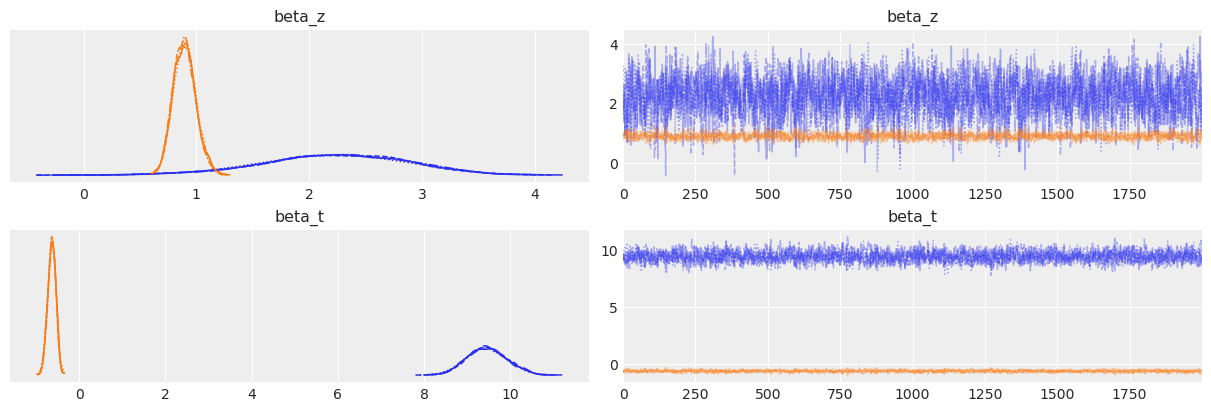

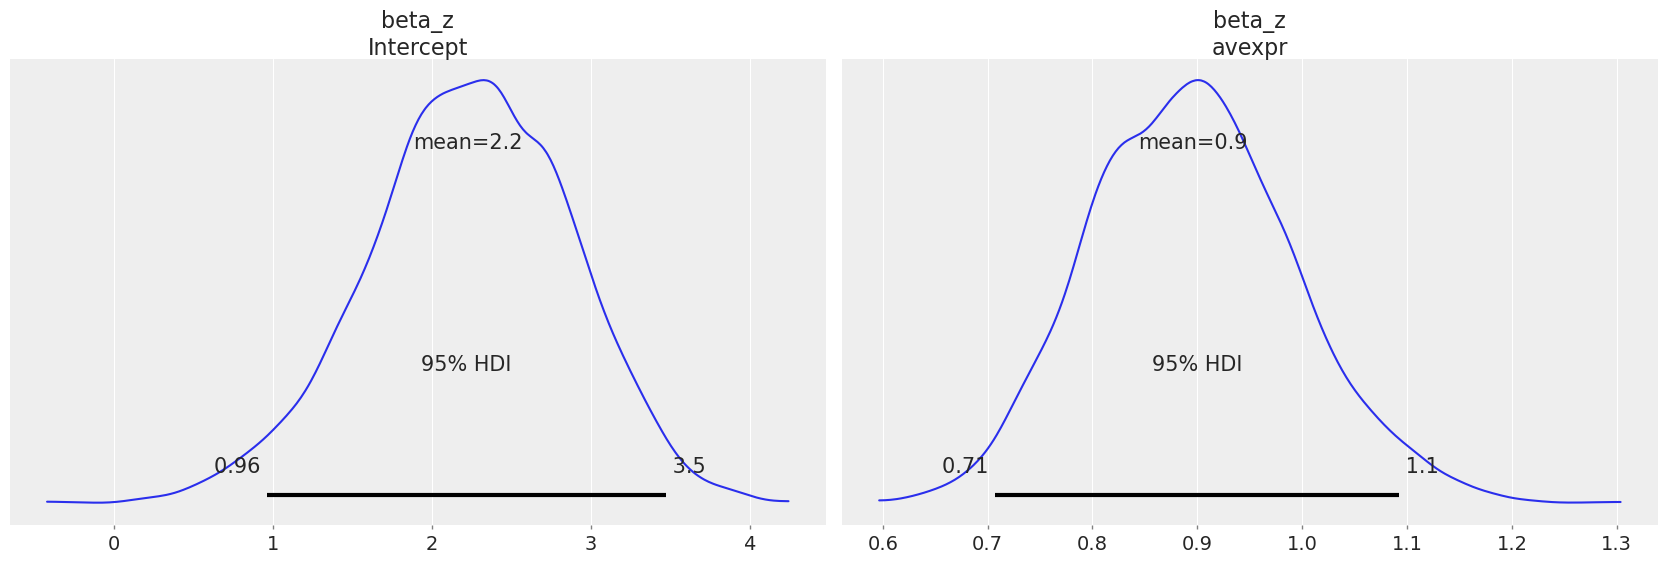

In [ ]:
idata = az.from_netcdf("ajr_iv_posterior.nc")
az.plot_trace(idata, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata, var_names=["beta_z"], hdi_prob=0.95)


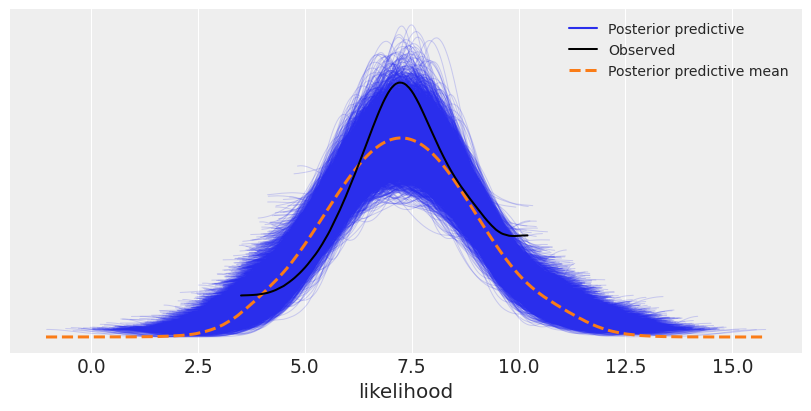

In [ ]:
idata = az.from_netcdf("ajr_iv_posterior.nc")

az.plot_ppc(
    idata,
    data_pairs={"logpgp95": "logpgp95"},   # {observed: predictive_var}
    figsize=(8, 4),
)



In [9]:
list(idata.posterior.data_vars)

['beta_t',
 'beta_z',
 'chol_cov',
 'chol_cov_corr',
 'chol_cov_stds',
 'cov',
 'mu_y',
 'mu_t',
 'mu']

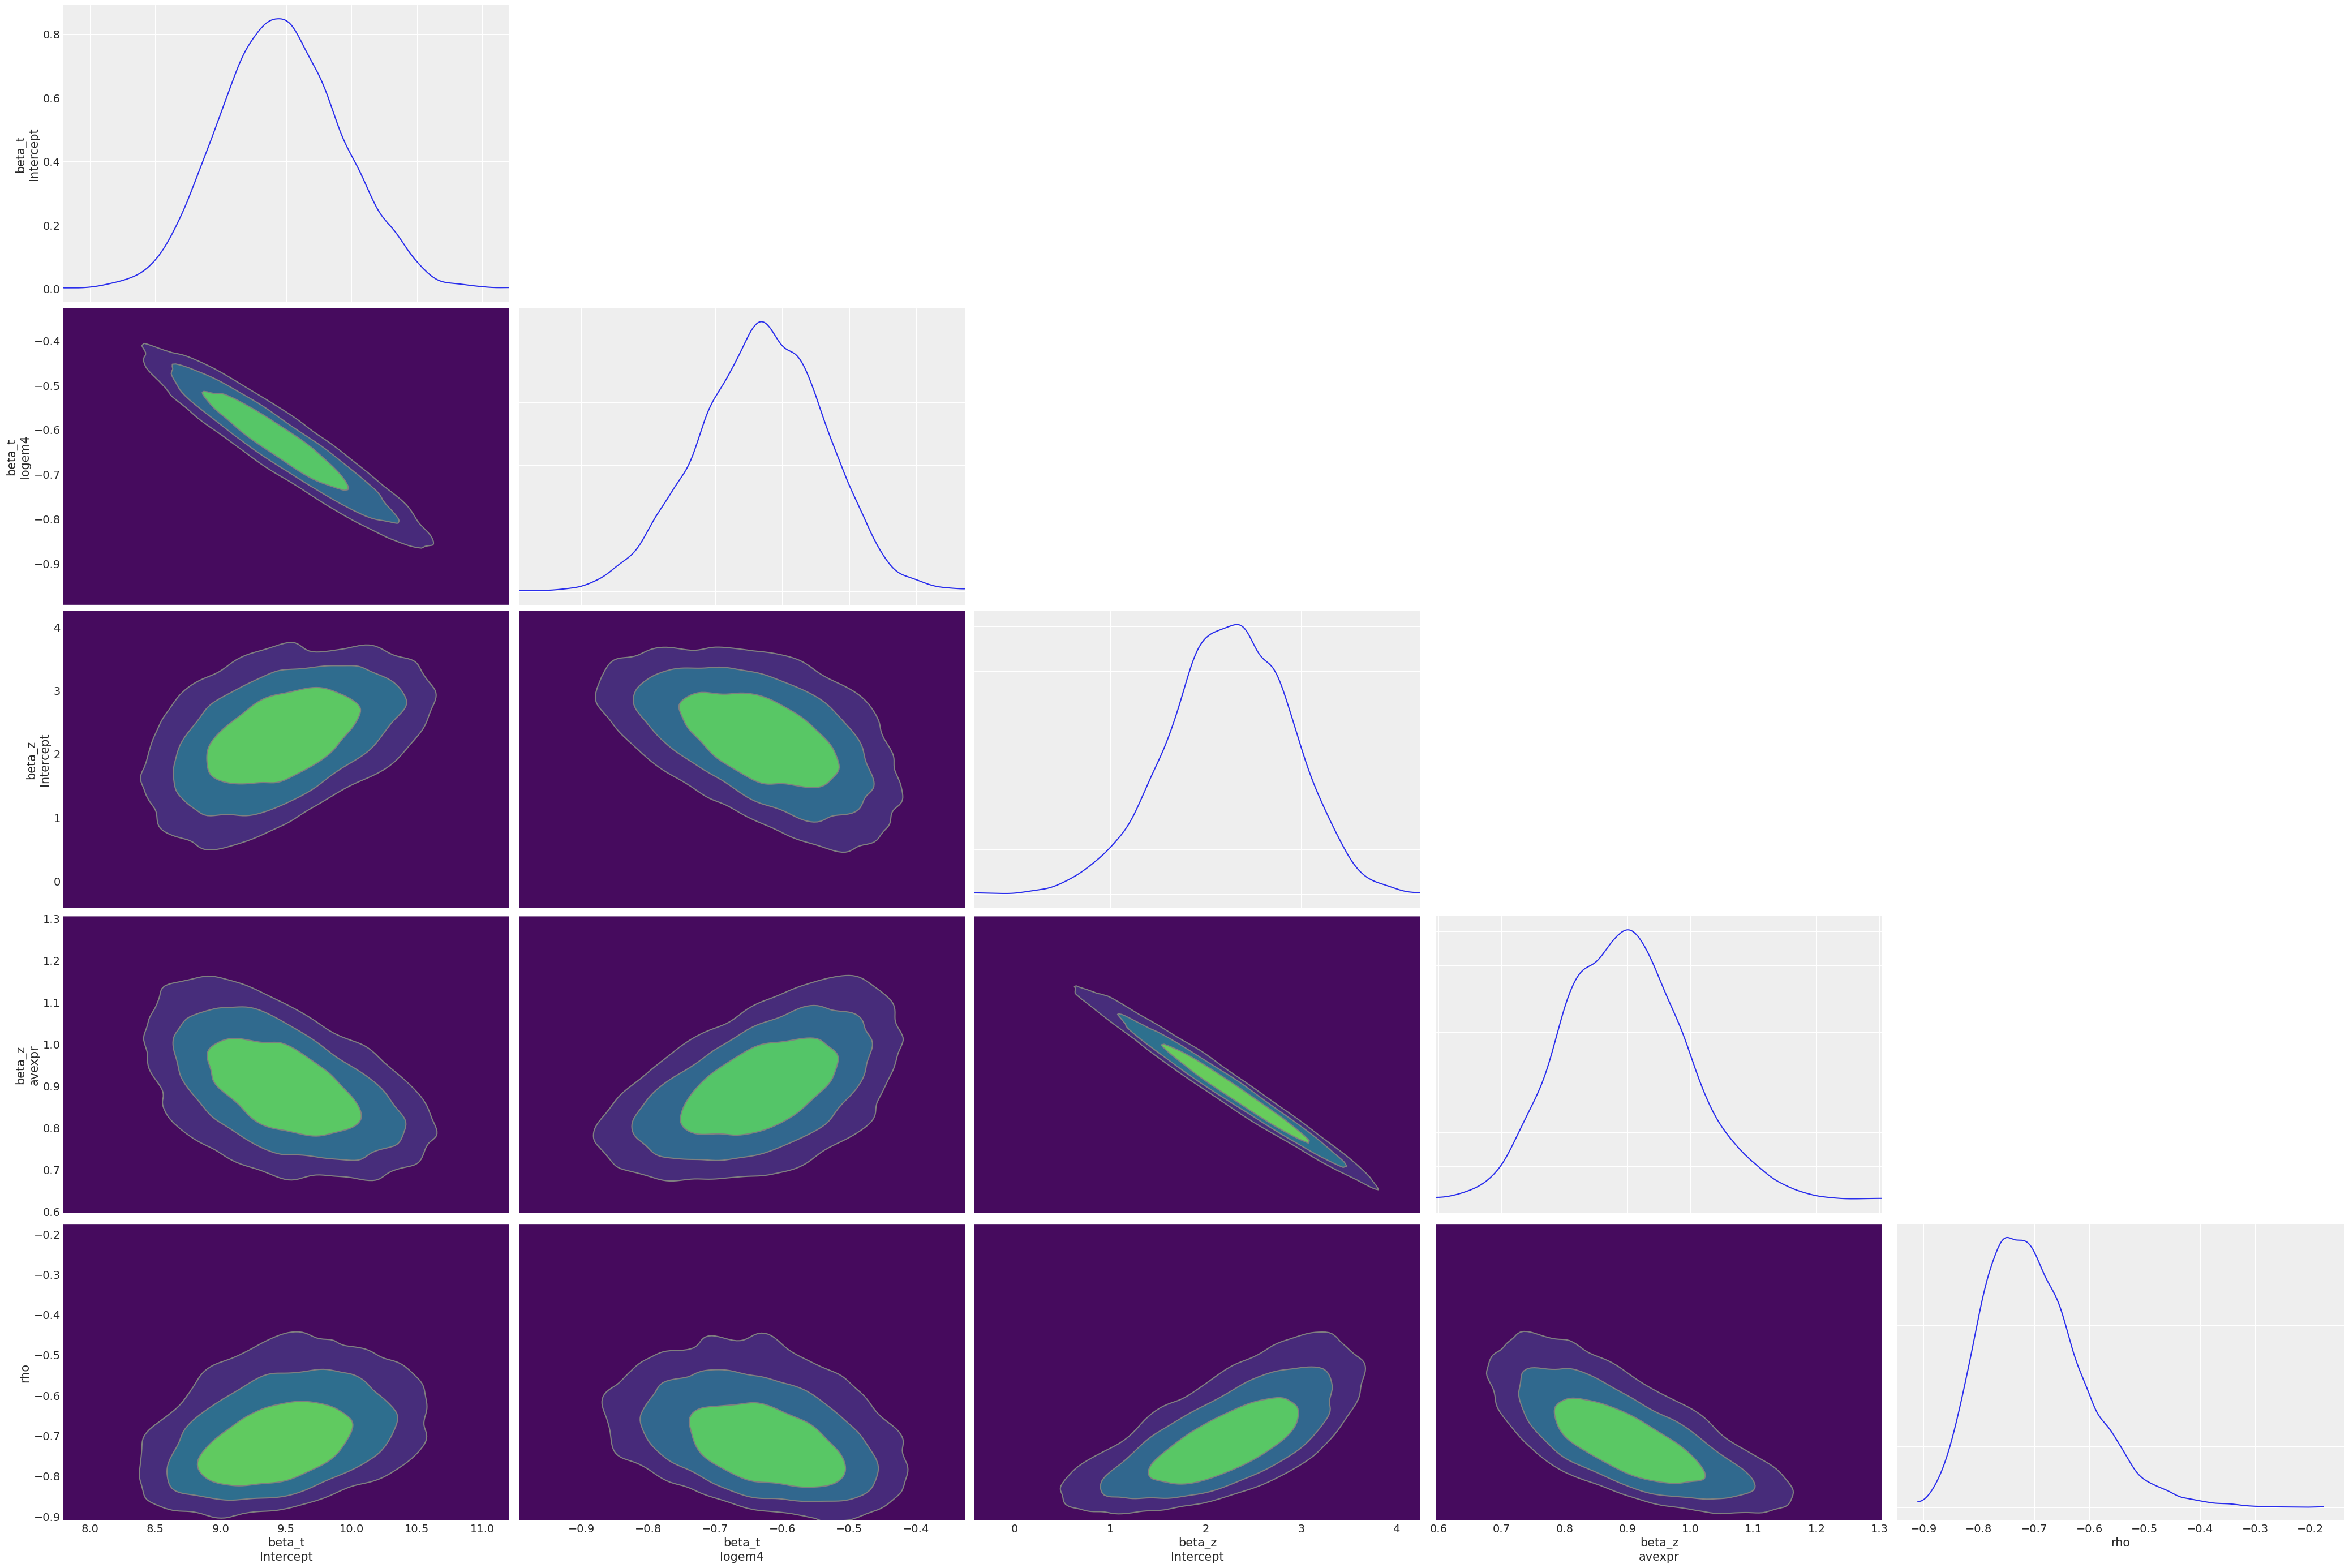

In [ ]:
# 1. pull out the pieces of the 2×2 covariance matrix
cov = idata.posterior["cov"]        # dims: (chain, draw, cov_dim_0, cov_dim_1)

σ_uv = cov.sel(cov_dim_0=0, cov_dim_1=1)       # off‑diagonal element
σ_u2 = cov.sel(cov_dim_0=0, cov_dim_1=0)       # variance of u
σ_v2 = cov.sel(cov_dim_0=1, cov_dim_1=1)       # variance of v

# 2. turn it into the correlation ρ
rho = σ_uv / (σ_u2**0.5 * σ_v2**0.5)

# 3. store it inside the InferenceData so ArviZ can see it
idata.posterior["rho"] = rho               # or idata = idata.assign(rho=rho)

# 
az.plot_pair(
    idata,
    var_names=["beta_t", "beta_z", "rho"],
    kind="kde",
    marginals=True,
    divergences=True,
)


In [ ]:
ajr.get_available_covariates(data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")

['africa', 'asia', 'lat_abst', 'loghjypl', 'other_cont', 'rich4']

In [21]:

iv2 = ajr.run(baseline_only=True, draws=2000, tune=1000, chains=4, cores=4, covariates=['asia', 'africa', 'other_cont', 'lat_abst'], data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta", netcdf_path="ajr_iv_posterior2.nc")

c:\Users\B375471\Anaconda3\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1630 seconds.
Sampling: [likelihood]


Output()

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]   2.086  0.818   0.518    3.577      0.017    0.010   
beta_z[avexpr]      1.003  0.129   0.751    1.234      0.003    0.002   
beta_z[asia]       -0.982  0.335  -1.632   -0.379      0.005    0.004   
beta_z[africa]     -0.500  0.258  -0.955    0.005      0.004    0.003   
beta_z[other_cont] -0.840  0.479  -1.775    0.035      0.007    0.005   
beta_z[lat_abst]   -0.948  0.659  -2.195    0.275      0.009    0.007   
beta_t[Intercept]   7.851  0.495   6.943    8.818      0.008    0.006   
beta_t[logem4]     -0.369  0.099  -0.549   -0.179      0.002    0.001   
beta_t[asia]        0.467  0.416  -0.293    1.276      0.006    0.005   
beta_t[africa]     -0.226  0.336  -0.867    0.389      0.005    0.004   
beta_t[other_cont]  1.042  0.562  -0.048    2.092      0.007    0.006   
beta_t[lat_abst]    2.019  0.710   0.668    3.316      0.009    0.007   

                    ess_bulk  ess_tail  r_hat  
be

<Axes: xlabel='likelihood'>

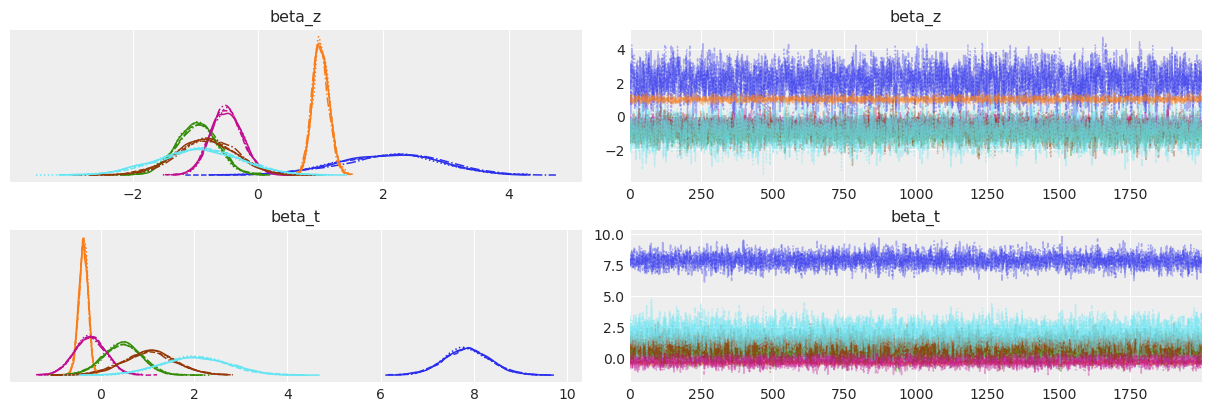

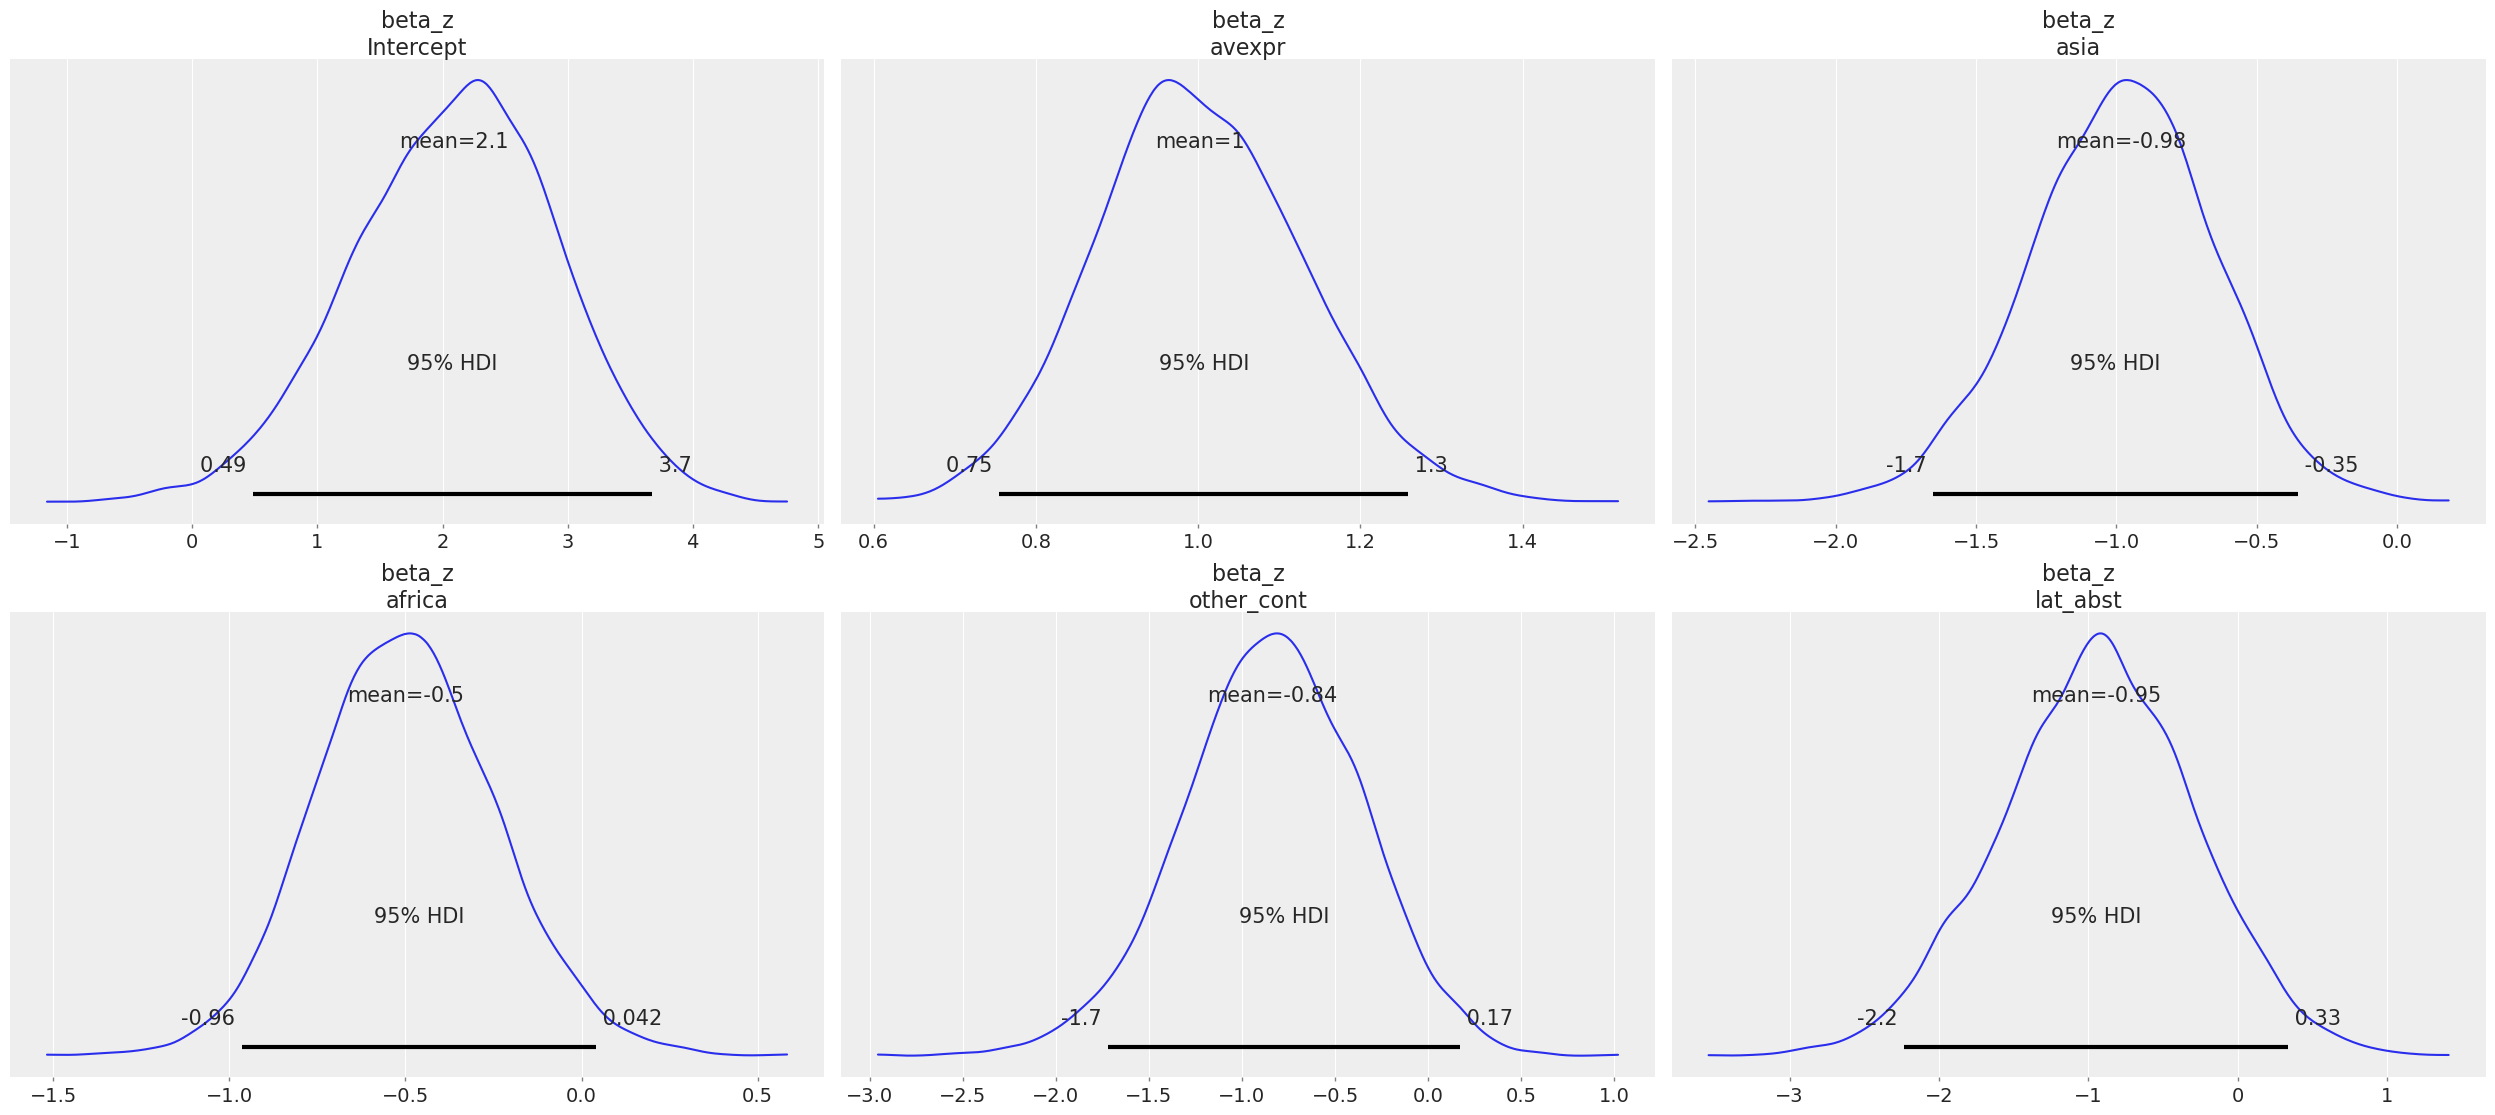

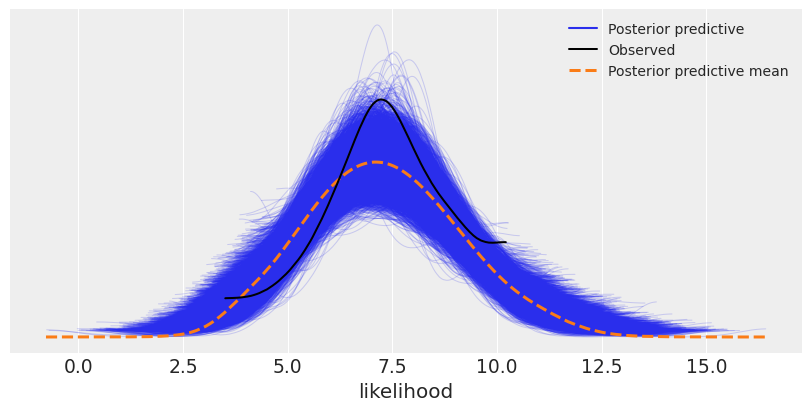

In [27]:
idata2 = az.from_netcdf("ajr_iv_posterior2.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)

az.plot_ppc(
    idata2,
    data_pairs={"logpgp95": "logpgp95"},   # {observed: predictive_var}
    figsize=(8, 4),
)

β_z components (trace plot colors): ['Intercept', 'avexpr', 'asia', 'africa', 'other_cont', 'lat_abst']
β_t components (trace plot colors): ['Intercept', 'logem4', 'asia', 'africa', 'other_cont', 'lat_abst']


AttributeError: 'numpy.ndarray' object has no attribute 'suptitle'

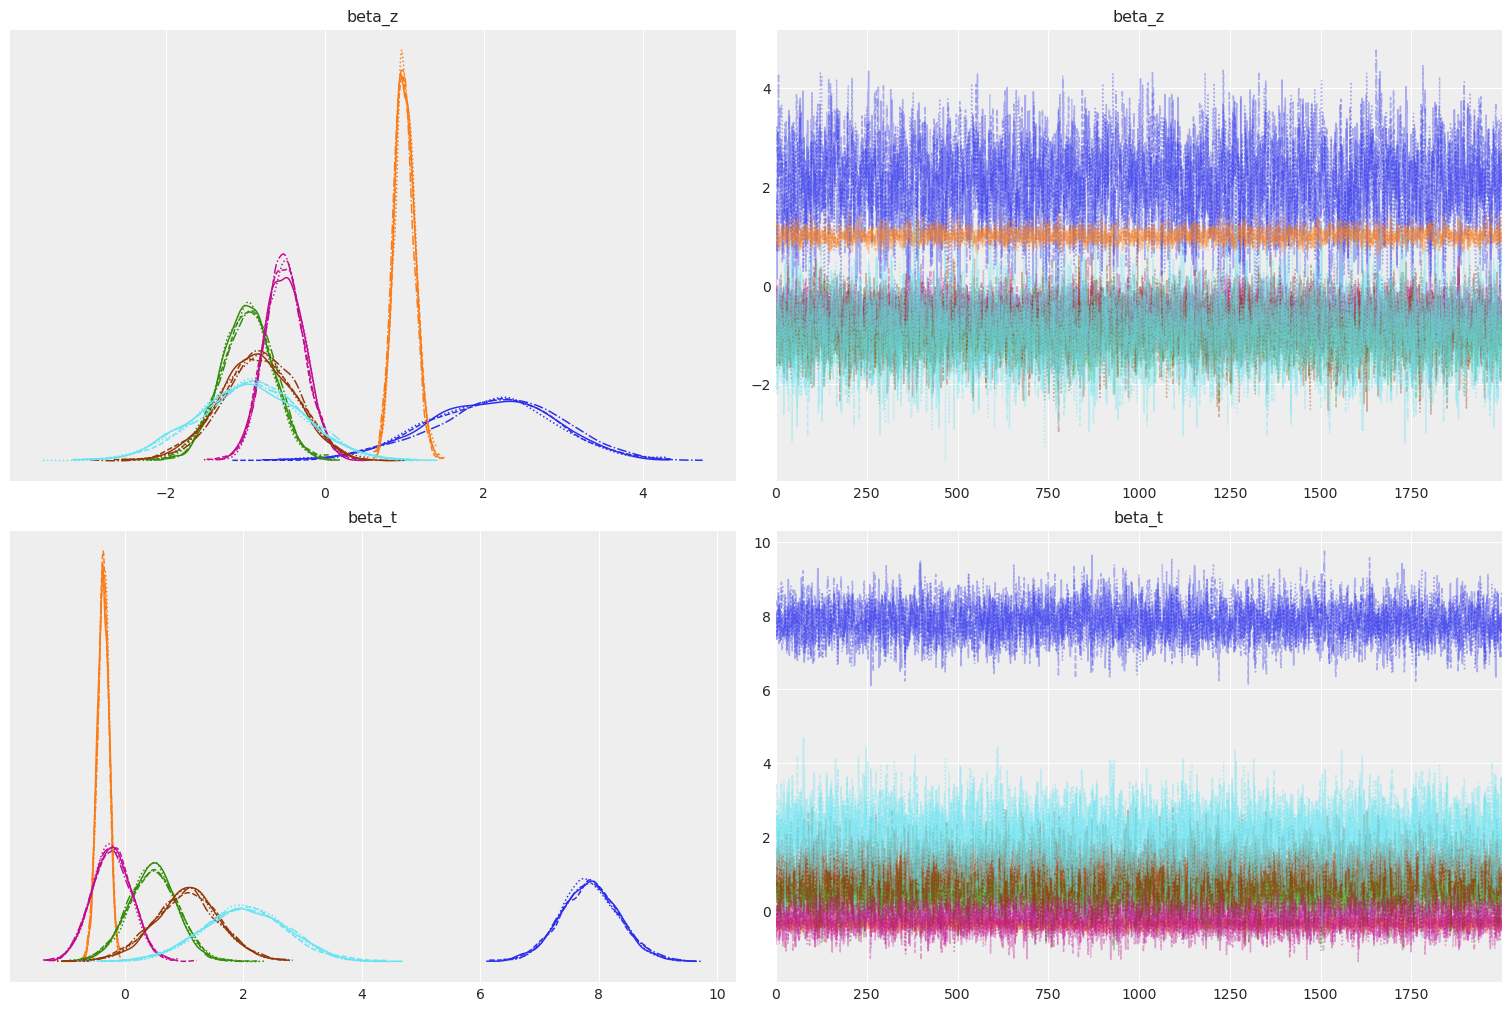

In [29]:
# Same trace plot as above but with variable labels added
import matplotlib.pyplot as plt

# Get the coordinate labels
beta_z_coords = list(idata2.posterior.coords['covariates'].values)
beta_t_coords = list(idata2.posterior.coords['instruments'].values)

print("β_z components (trace plot colors):", beta_z_coords)
print("β_t components (trace plot colors):", beta_t_coords)

# Create the trace plot with enhanced labeling
fig = az.plot_trace(idata2, var_names=["beta_z", "beta_t"], figsize=(15, 10))

# Add variable labels to the plot
fig.suptitle("Trace Plots with Variable Labels\n" + 
             f"β_z components: {', '.join(beta_z_coords)}\n" +
             f"β_t components: {', '.join(beta_t_coords)}", 
             fontsize=12, y=0.98)

plt.tight_layout()
plt.show()

c:\Users\B375471\Anaconda3\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta_t\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nlogem4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nasia'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nafrica'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nother_cont'>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nlat_abst'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_z\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta_t\nIntercept', ylabel='beta_z\navexpr'>,
        <Axes: xlabel='beta_t\nlogem4'>, <Axes: xlabel='beta_t\nasia'>,
        <

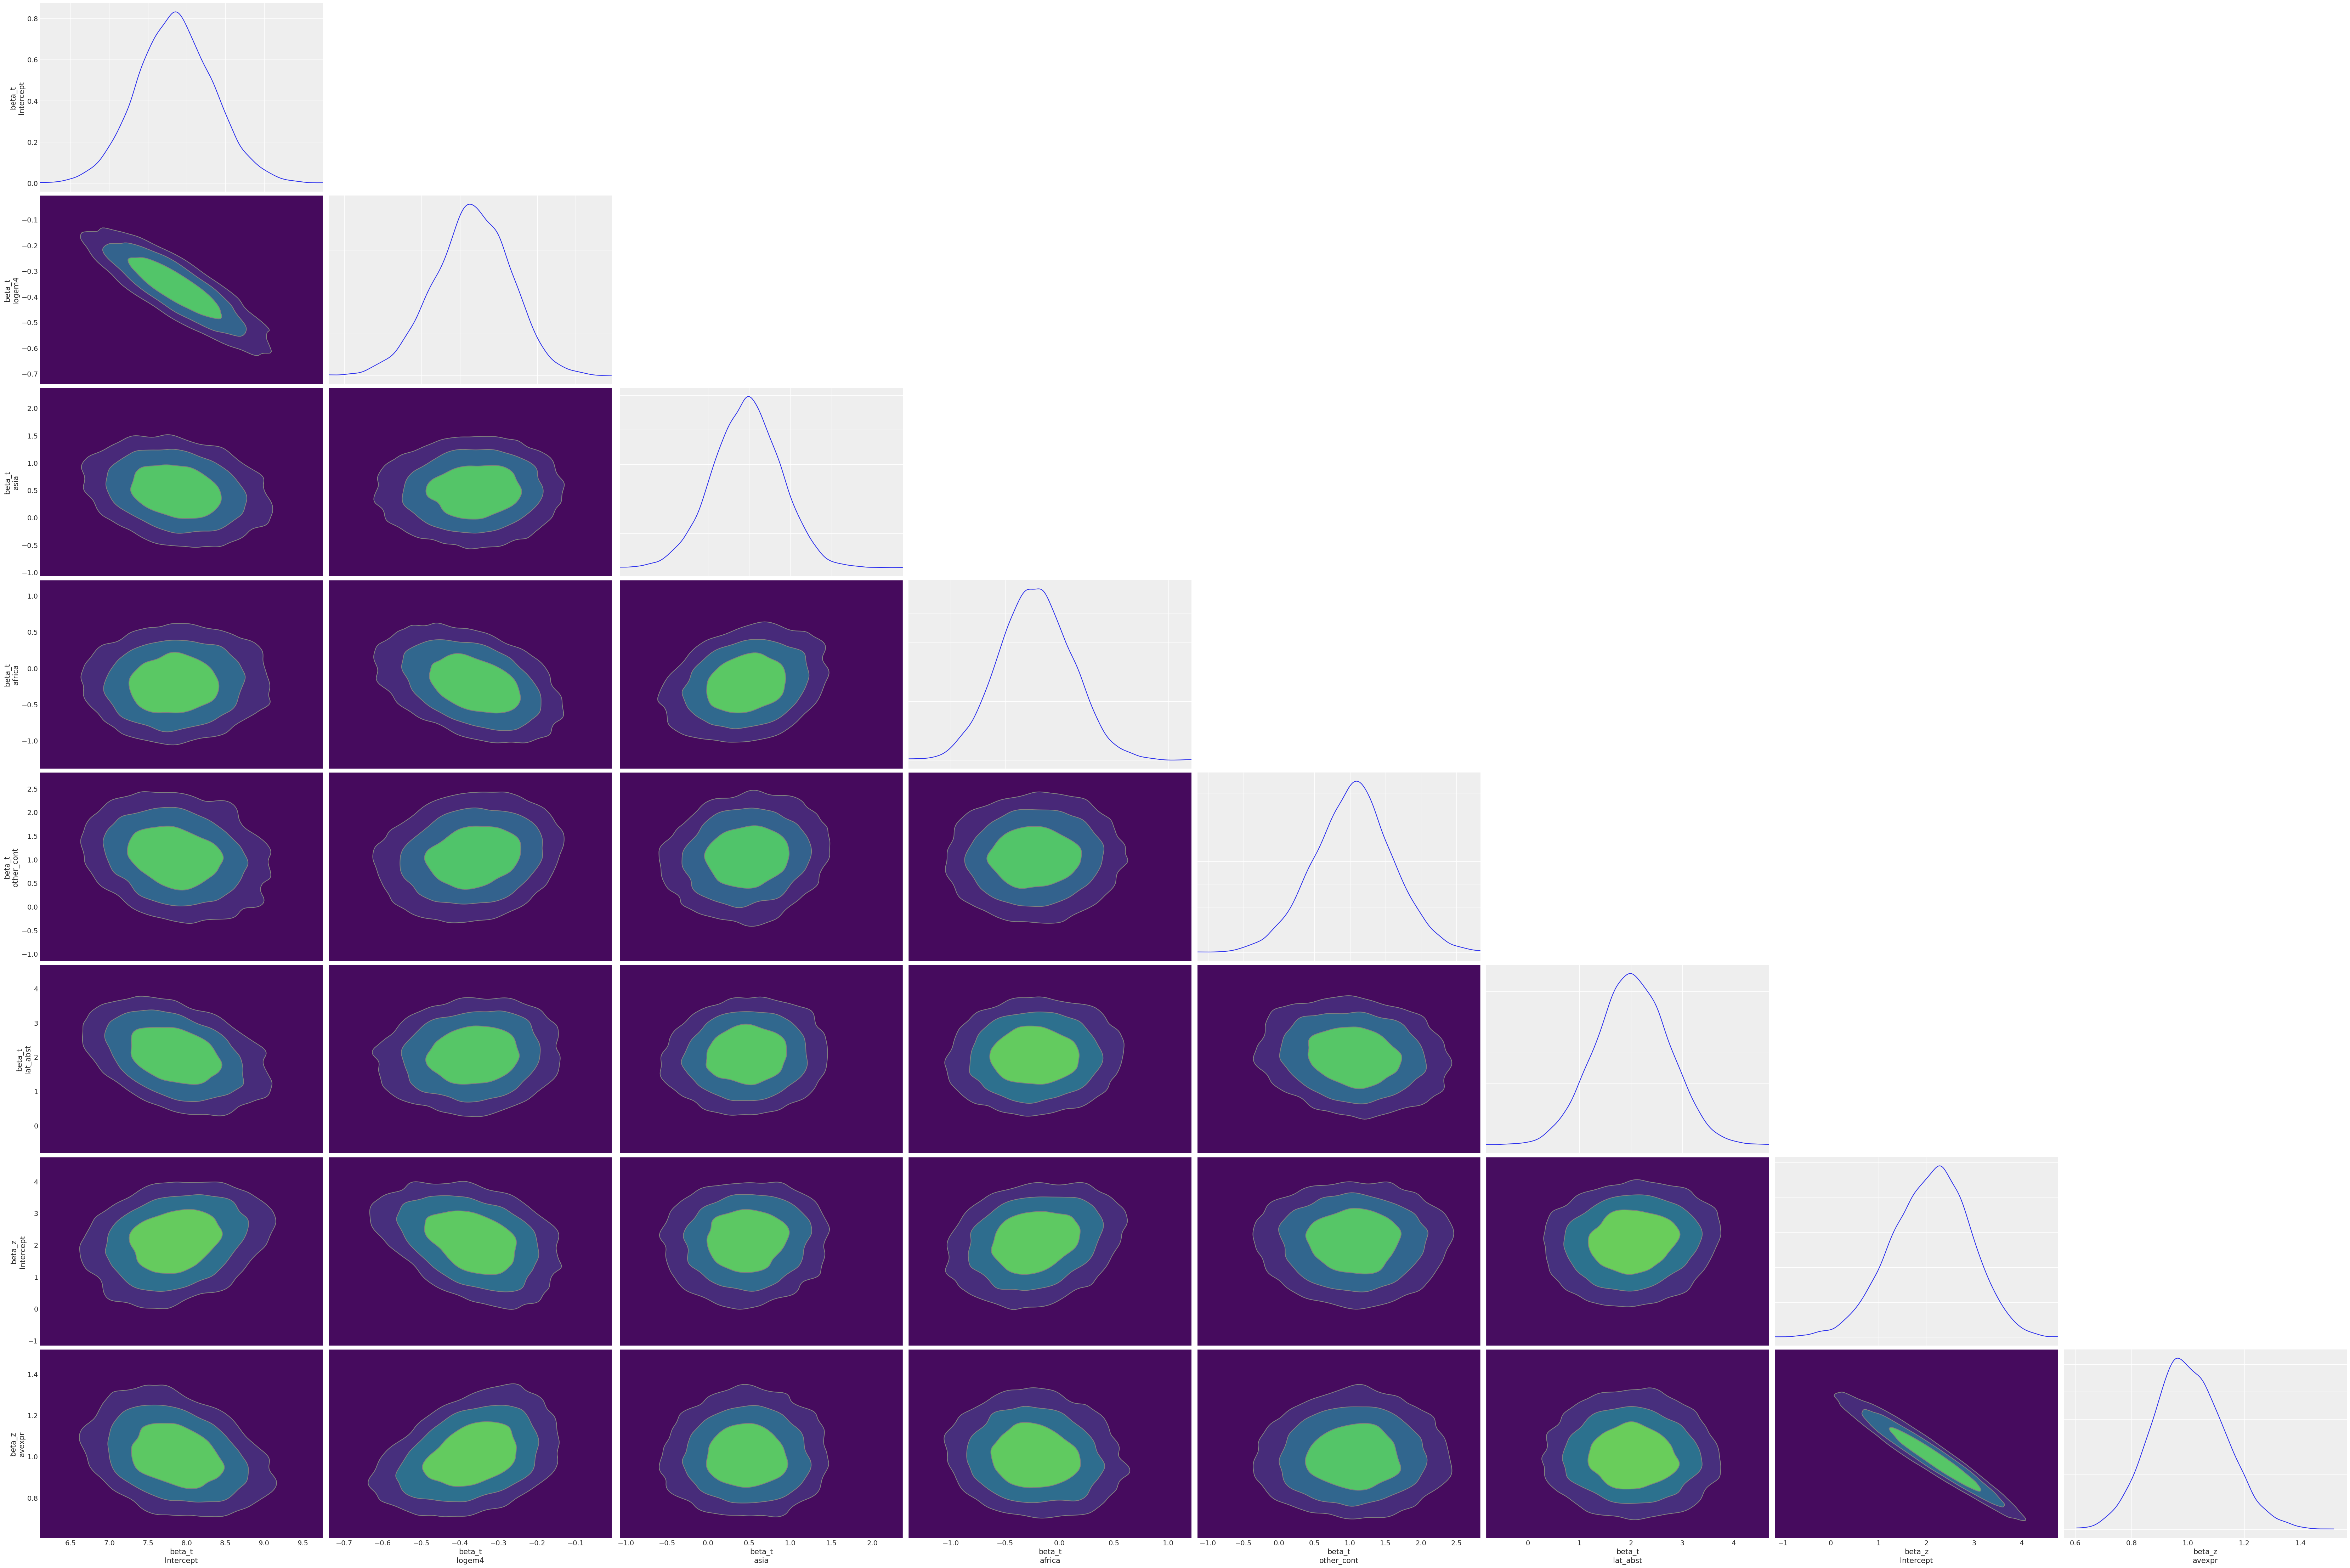

In [23]:
# 1. pull out the pieces of the 2×2 covariance matrix
cov = idata2.posterior["cov"]        # dims: (chain, draw, cov_dim_0, cov_dim_1)

σ_uv = cov.sel(cov_dim_0=0, cov_dim_1=1)       # off‑diagonal element
σ_u2 = cov.sel(cov_dim_0=0, cov_dim_1=0)       # variance of u
σ_v2 = cov.sel(cov_dim_0=1, cov_dim_1=1)       # variance of v

# 2. turn it into the correlation ρ
rho = σ_uv / (σ_u2**0.5 * σ_v2**0.5)

# 3. store it inside the InferenceData so ArviZ can see it
idata2.posterior["rho"] = rho               # or idata = idata.assign(rho=rho)

# 
az.plot_pair(
    idata2,
    var_names=["beta_t", "beta_z", "rho"],
    kind="kde",
    marginals=True,
    divergences=True,
)